# Week 4 - Univariate Analysis, part 2
Keshia-Lee Martin<br>
OMDS-ModB2<br>
Media and Entertainment<br>

Datasets: <br>
[Movielens](https://grouplens.org/datasets/movielens/latest/), [Dataset Details](https://files.grouplens.org/datasets/movielens/ml-latest-small-README.html) [dropping from analysis]<br>
[4 Services Streaming Movies and Tv](https://www.kaggle.com/datasets/sc0v1n0/4-services-streaming-movies-and-tv/data)<br>
[Movie Box Office Dataset (2000-2024)](https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024)

# Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

### Response 
Both graphs are adaquate and tell a story. The following are the pros and cons:

<b>Histogram - Pros:</b>
1. This shows the full distribution shape of the data, which is right skewed.
2. It is showing the frequency of the drugs at each cost point, directly showing their price bracket.
3. Visibilty shows how much of the drugs are on the "cheaper" end compared to the others.

<b>Histogram - Cons:</b>
1. This is less percise for what we're looking for, which is how much more the expensive drugs tend to cost. 

<b>Box Plot - Pros</b>
1. This is more precise and shows the quantiles, median and the outliers.
2. This is answering the question of the expensive drugs, which are the outliers, highlighting them extremely well.

<b>Box Plot - Cons</b>
1. The box plot doesn't show the distribution. We cannot see the shapes or any patterns.
2. There is no way of known what the sample size is of the data. Even outliers may overlap.

In conclusion, the Box Plot is the best option for this question. We can clearly see how much the more expensive drugs tend to cost, compared to the others which are within the range and quantile of the mean.

To improve the box plot, I would expand the y axis in order to show less overlap of the prices. I would also add a title, label the y axis, and change the name of the x axis. I would also possibly add some more color to the outliers, just to show how many they are and to make the graph more engaging.

In [242]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

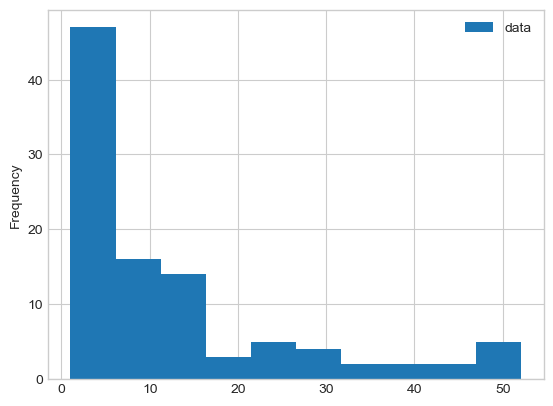

In [243]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

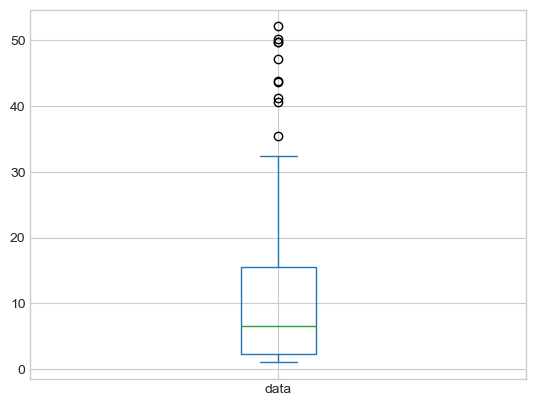

In [244]:
df.plot.box()

# Univariate Analysis of Movie Datasets

In [245]:
import seaborn as sns
import matplotlib.pyplot as plt

df_box_office = pd.read_csv('movie_box_office_v1.csv')
df_stream = pd.read_csv('movie_tv_stream_v2.csv')

## Streaming Movies and TV Dataset

### Histograms

Below we will begin to make histograms of all of the necessarily columns. This will show us the distribution of the data, the count in range, and show us any necessary patterns that will enhance our analysis.

The following columns will not have histograms:
- title
- director
- cast

As a quick update, the year added date and year added year will be changed to integers from floats. This will be modified in an updated fix in the csv.

In [246]:
# CHANGING TYPE FROM FLOAT TO INTEGER
df_stream['year_added_platform'] = df_stream['year_added_platform'].astype('Int64')
df_stream['day_added_platform'] = df_stream['day_added_platform'].astype('Int64')

In [247]:
# PRINTING THE LIST OF COLUMNS
print('--------------------------')
print('List of Columns (120 columns)')
print('--------------------------\n')
print(df_stream.columns.tolist())

--------------------------
List of Columns (120 columns)
--------------------------

['movie_or_tv_show', 'title', 'director', 'cast', 'date_added_platform', 'release_year', 'channel_streaming', 'Unnamed: 0', 'action', 'actionadventure', 'adult', 'adventure', 'animals', 'animation', 'anime', 'anthology', 'arthouse', 'arts', 'biographical', 'black', 'british', 'buddy', 'cartoons', 'children', 'classic', 'classics', 'comedies', 'comedy', 'coming', 'concert', 'cooking', 'crime', 'cult', 'dance', 'documentaries', 'documentary', 'docuseries', 'drama', 'dramas', 'faith', 'family', 'fantasy', 'fitness', 'game', 'health', 'historical', 'history', 'horror', 'independent', 'international', 'kids', 'latino', 'lgbtq', 'lifestyle', 'military', 'music', 'musical', 'mystery', 'news', 'reality', 'romance', 'romantic', 'science', 'scifi', 'series', 'spanishlanguage', 'special', 'sports', 'suspense', 'talk', 'thriller', 'thrillers', 'unscripted', 'variety', 'western', 'young', 'competition', 'culture', 

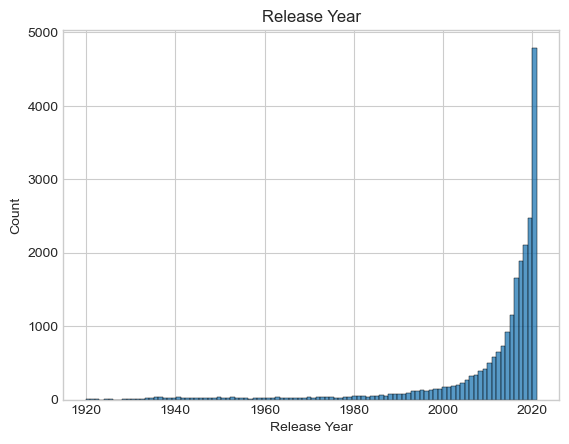

---------------------
MINIMUM RELEASE YEAR: 1920
MAX RELEASE YEAR: 2021
MEAN: 2010.8112444560397
MEDIAN: 2016.0
MODE: 2019
---------------------


In [248]:
# RELEASE HISTOGRAMS
sns.histplot(df_stream["release_year"], bins=100)
plt.title('Release Year')
plt.xlabel('Release Year')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RELEASE YEAR: {np.min(df_stream["release_year"])}')
print(f'MAX RELEASE YEAR: {np.max(df_stream["release_year"])}')
print(f'MEAN: {np.mean(df_stream["release_year"])}')
print(f'MEDIAN: {np.median(df_stream["release_year"])}')
print(f'MODE: {(df_stream["release_year"]).mode()[0]}')
print('---------------------')

First, we have the <b>Release Year</b> left skewed histogram. Most of the movies on the streaming platforms had a release date in the 2000s. In fact, the most were in the year 2020 and beyond. Streaming services became incredibly popular as the years have went by. With more competition, more streaming services have entered the consumer race, adding more and more of the latest movies and tv shows to their catalog. The newer the movie is and if the release date is closest to the current day, streaming services will push to have them on their platform. This increases viewership, as many people wait for movies that are in the theatres to be released on a streaming service.

There are multiple outlies as early as 1940. The minimum release year is 1920, with the maximum release year being in 2021. The mean is ~2010.8, the median is 2020, and the mode is 2019. 

The bin number does not affect the histogram until past 100. Then, the release date holes show for the programs that are on the streaming services.

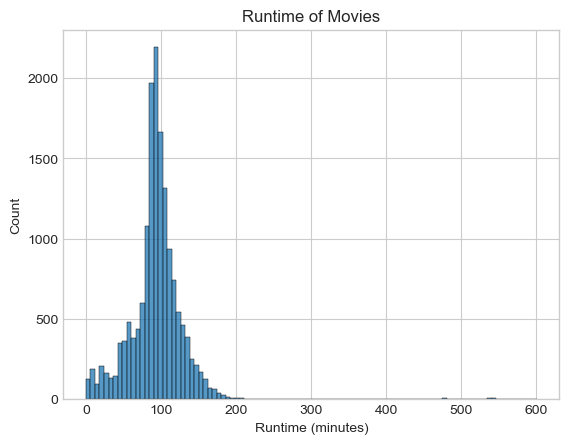

---------------------
MINIMUM RUNTIME: 0.0
MAX RUNTIME: 601.0
MEAN: 93.63885242827676
MEDIAN: nan
MODE: 90.0
---------------------


In [249]:
# RUNTIME OF MOVIES HISTOGRAM
sns.histplot(df_stream["runtime_minutes"], bins=100)
plt.title('Runtime of Movies')
plt.xlabel('Runtime (minutes)')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RUNTIME: {np.min(df_stream["runtime_minutes"])}')
print(f'MAX RUNTIME: {np.max(df_stream["runtime_minutes"])}')
print(f'MEAN: {np.mean(df_stream["runtime_minutes"])}')
print(f'MEDIAN: {np.median(df_stream["runtime_minutes"])}')
print(f'MODE: {(df_stream["runtime_minutes"]).mode()[0]}')
print('---------------------')

The <b>Runtime of Movies</b> histogram shows us the length of movies in minutes. This has a nice bell curve that is right skewed. Most movies are in the 100 minute range, ~ an hour and half. This "sweet spot" comes from a person's attention span. As the length runtime in minutes continues in the histogram, the number of movies in those ranges go down. This makes sense for streaming services to have movies in this range as they can lead to another movie or tv show being watched.

There are outliers that are past 450 in runtime, which with further analysis can review the movie and genre details of the entry.

There is a minimum runtime of 0 (run time was not reported and simply reported as 0 versus leaving blank), a max runtime of 601 minutes, a mean runtime of 93.64, a median of nan (data missing), and a mode of 90 minutes.

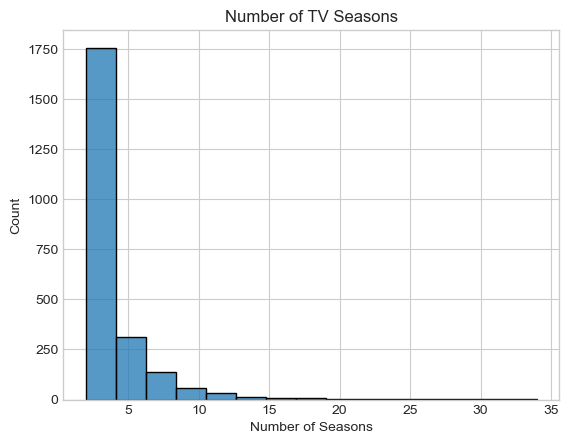

---------------------
MINIMUM RUNTIME: 0.0
MAX RUNTIME: 601.0
MEAN: 93.63885242827676
MEDIAN: nan
MODE: 90.0
---------------------


In [250]:
sns.histplot(df_stream["tv_season"], bins=15)
plt.title('Number of TV Seasons')
plt.xlabel('Number of Seasons')
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RUNTIME: {np.min(df_stream["runtime_minutes"])}')
print(f'MAX RUNTIME: {np.max(df_stream["runtime_minutes"])}')
print(f'MEAN: {np.mean(df_stream["runtime_minutes"])}')
print(f'MEDIAN: {np.median(df_stream["runtime_minutes"])}')
print(f'MODE: {(df_stream["runtime_minutes"]).mode()[0]}')
print('---------------------')

The <b>Number of Seasons</b> histogram is right skewed, show that most tv shows on the streaming services only have 1-5 seasons. This is the typical range on many tv shows on streaming services. Now, nearly every streaming service has their own tv shows and miniseries. With miniseries being only one season, multiple shows being cut after the first season due to lower viewership or budget, and show quality decreasing after multiple seasons, streaming services do not host many shows with more than 5 seasons. Next, it would be very interesting to see the years of release against the tv seasons.

### Histogram Variants

<b>Swarm Plots</b> can be used when there is a categorical variable, a numeric variable, and when one wants to see every single point without any overlap. With the amount of points in the data set, the swarm plot is overcrowded and cannot be used for this specific dataset.


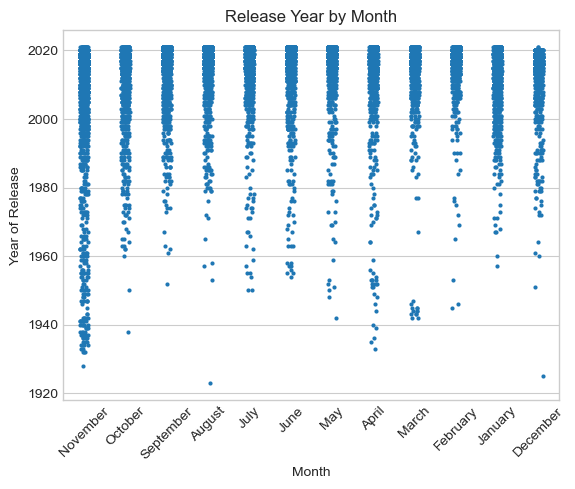

---------------------
MINIMUM RUNTIME: 0.0
MAX RUNTIME: 601.0
MEAN: 93.63885242827676
MEDIAN: nan
MODE: 90.0
---------------------


In [251]:
sns.stripplot(data=df_stream, x="month_name", y="release_year", size=3)
plt.ylabel('Year of Release')
plt.xlabel('Month')
plt.xticks(rotation=45)

plt.title("Release Year by Month")
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RUNTIME: {np.min(df_stream["runtime_minutes"])}')
print(f'MAX RUNTIME: {np.max(df_stream["runtime_minutes"])}')
print(f'MEAN: {np.mean(df_stream["runtime_minutes"])}')
print(f'MEDIAN: {np.median(df_stream["runtime_minutes"])}')
print(f'MODE: {(df_stream["runtime_minutes"]).mode()[0]}')
print('---------------------')

The <b>Strip Plot</b> shows something similar to the graphs above. Most movies on the streaming services are released around 2020. The interesting thing here is that many older movies look to be released in the month of November. But, these can overlap. This is something where the graph should be expanded and more analysis in the length (number) of movies are in fact released on each date, as well as the month in which the streaming services have added the data to their platforms.



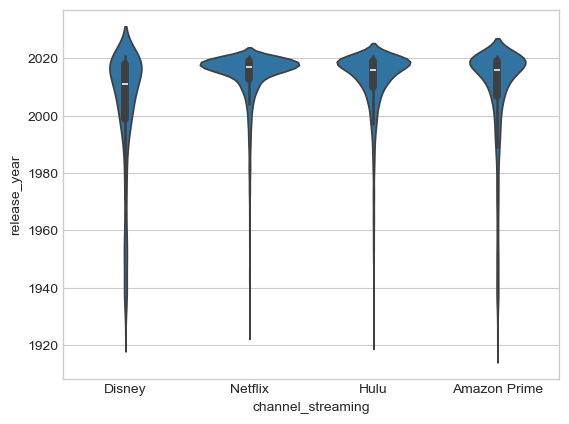

---------------------
MINIMUM RUNTIME: 0.0
MAX RUNTIME: 601.0
MEAN: 93.63885242827676
MEDIAN: nan
MODE: 90.0
---------------------


In [252]:
sns.violinplot(data=df_stream, x="channel_streaming", y="release_year")
plt.show()

# MIN, MAX, MEAN, MEDIAN, MODE
print('---------------------')
print(f'MINIMUM RUNTIME: {np.min(df_stream["runtime_minutes"])}')
print(f'MAX RUNTIME: {np.max(df_stream["runtime_minutes"])}')
print(f'MEAN: {np.mean(df_stream["runtime_minutes"])}')
print(f'MEDIAN: {np.median(df_stream["runtime_minutes"])}')
print(f'MODE: {(df_stream["runtime_minutes"]).mode()[0]}')
print('---------------------')

The <b>Violin Plot</b> shows a very similar analysis, but by streaming platform. The Disnet and Amazon platforms have thicker lines compared to Netflix and Hulu for the tv shows and movies they have that have older release dates. Disney especially has some more between roughly 1960 and 1930, when many of their classics such as Sleeping Beauty and Snow White were released. Netflix has a wider range of movies that are in the late 2000's compared to the other platforms. Disney's becomes quite thin, with less tv show and movies that were released in the late 2000's. This is likely due to more original series, miniseries, and movies that are added to Netflix, Hulu, and Amazon Prime's platforms.

### Bar Graphs

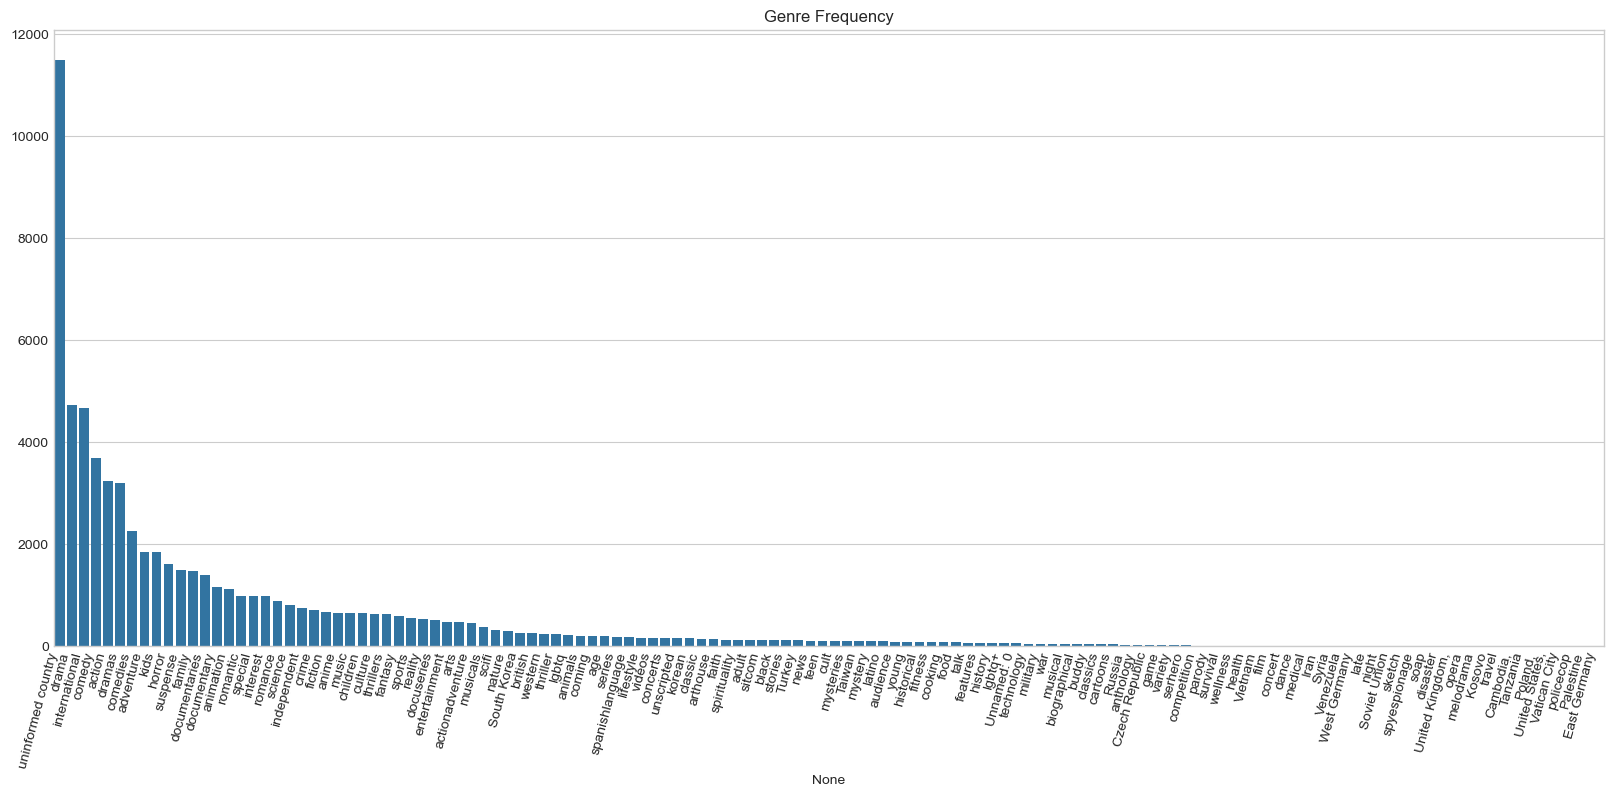

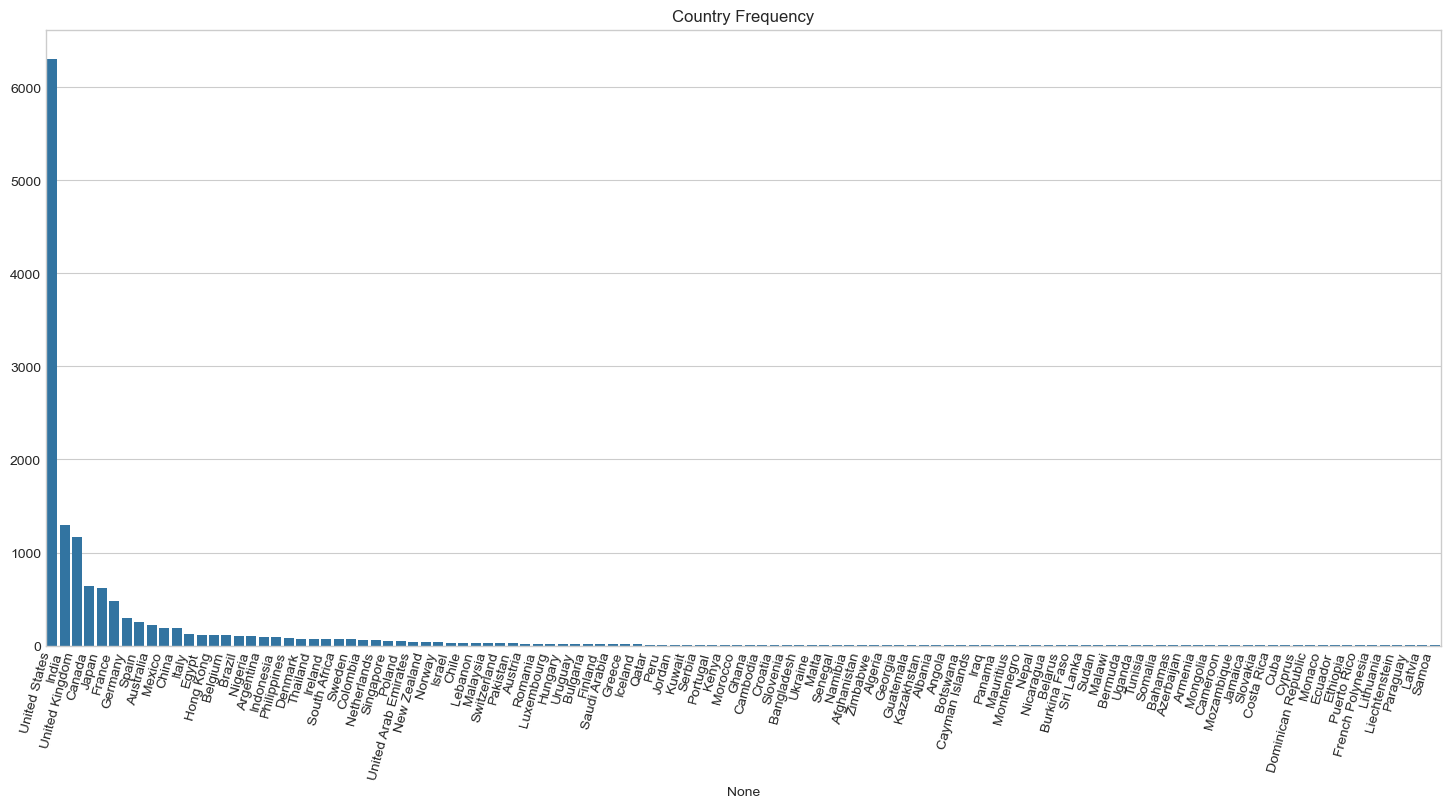

In [253]:
# BAR GRAPH FOR COUNTRIES AND GENRES

# TO IDENTIFY COUNTRY COLUMNS
try:
  import pycountry
except ModuleNotFoundError:
  import sys
  import subprocess
  subprocess.check_call([sys.executable, "-m", "pip", "install", "pycountry"])
  import pycountry

# FINDS ALL OF THE ENCODED COLUMNS
encoded_cols = [
    col for col in df_stream.columns
    if df_stream[col].dropna().isin([0, 1]).all()
]

# # FOR TESTING
# print(f"Total encoded columns found: {len(encoded_cols)}")
# print(f"First 20 encoded columns: {encoded_cols[:20]}\n")


# SEPARATES THE GENRES COLUMNS FROM THE COUNTRIES COLUMNS
# THERE IS A MIX OF REGIONS WITH COUNTRIES THAT NEED TO BE SEPARATED
true_country_names = [c.name for c in pycountry.countries]

# REGION NAMES THAT ARE NOT MATCHING SOME OF THE COLUMNS FROM THE DATA
country_region = set(true_country_names) | {"International", "Europe", "Asia", 
                                            "Africa", "Latin_America", "Middle_East", "Worldwide", "Global",
                                             "Czech Republic", "South Korea","North Korea", "Russia","Vatican City","Kosovo","Palestine","Iran","Syria","Taiwan","Tanzania","Turkey","Vietnam",
                                             # Historical names
                                             "East Germany","West Germany","Soviet Union",
                                             }

# IMPROVED MATCHING TO CATCH UNDERSCORES
country_cols = []
genre_cols = []

for col in encoded_cols:
    # MAKING SURE COLUMNS ARE IN SIMILAR FORMAT BY COVERING TO LOWERASE, REMOVING INCORRECT COMMA PLACEMENT
    col_normalized = col.strip().rstrip(',').lower().replace('_', ' ')
    
    # CHECK FOR MATCHING COLUMNS
    is_country = any(
        col_normalized == country.lower() 
        for country in country_region
    )
    
    if is_country:
        country_cols.append(col)
    else:
        genre_cols.append(col)

# CHECKING/DEBUG
# print(f"Countries identified ({len(country_cols)}): {sorted(country_cols)}\n")
# print(f"Genres identified ({len(genre_cols)}): {sorted(genre_cols)}\n")

country_cols = [col for col in encoded_cols if col in true_country_names]
genre_cols = [col for col in encoded_cols if col not in true_country_names]

# LOOPING THROUGH THE GENRES
genre_counts = df_stream[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(20, 8))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.xticks(rotation=75, ha='right')
plt.title("Genre Frequency")
plt.show()

# LOOPING THROUGH THE COUNTRIES
country_counts = df_stream[country_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(18, 8))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.xticks(rotation=75, ha='right')
plt.title("Country Frequency")
plt.show()



This has come across as a major issue with the encoding of the data. It appears that time combination of multiple encoding has combined genres with some countries. This data will have to be re-cleaned to change countries back to it's original format and splitting the movies that have multiple production companies across columns.

Based on this data so far, the United States has the most movies on the streaming services. There are also a lot of movies that do not have an identified country.

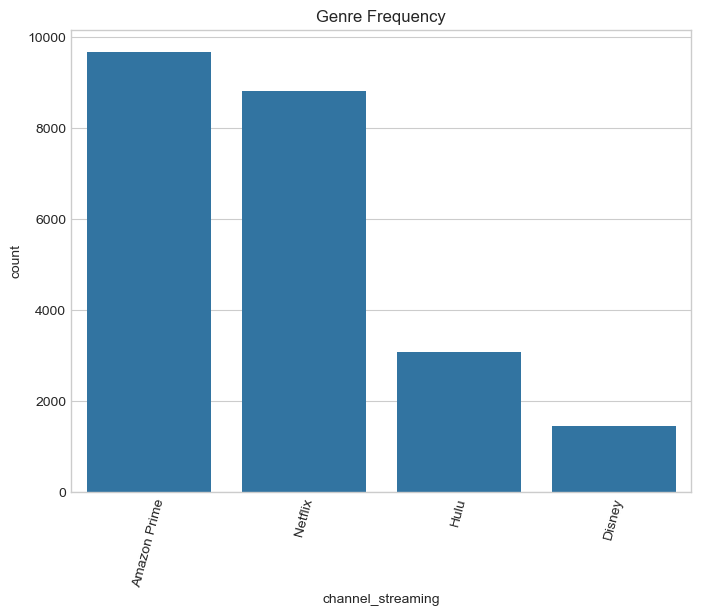

In [256]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_stream, x='channel_streaming', order=df_stream['channel_streaming'].value_counts().index)
plt.xticks(rotation=75)
plt.title("Genre Frequency")
plt.show()

Amazon has the most programs on their platform followed by Netflix, Hulu and Disney.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

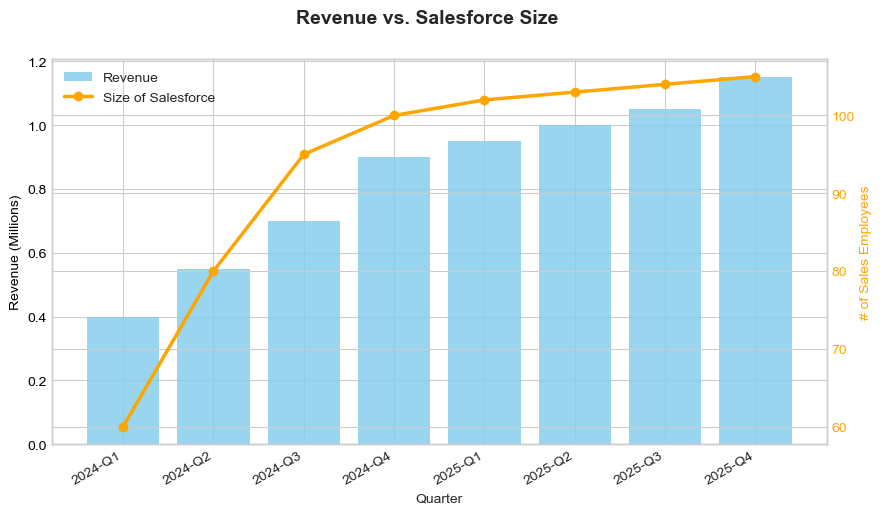

In [ ]:
# SAMPLE DATA
year_quarters = ["2024-Q1", "2024-Q2", "2024-Q3", "2024-Q4",
                 "2025-Q1", "2025-Q2", "2025-Q3", "2025-Q4"
                 ]
revenue = [0.4, 0.55, 0.7, 0.9, 0.95, 1.0, 1.05, 1.15]
salesforce = [60, 80, 95, 100, 102, 103, 104, 105]

x = np.arange(len(year_quarters))
fig, ax1 = plt.subplots(figsize=(10, 5))

# REVENUE BAR CHART
bar_width = 0.8
bars = ax1.bar(
    x,
    revenue,
    width=bar_width,
    color= "skyblue",
    alpha=0.85,
    label="Revenue"
)

ax1.set_xlabel("Quarter")
ax1.set_ylabel("Revenue (Millions)", color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_xticks(x)
ax1.set_xticklabels(year_quarters, rotation=30, ha="right")

# SECOND AXIS
ax2 = ax1.twinx()
line = ax2.plot(
    x,
    salesforce,
    color="orange",
    marker="o",
    linewidth=2.5,
    label="Size of Salesforce"
)

ax2.set_ylabel("# of Sales Employees", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# TITLE AND LEGEND
fig.suptitle("Revenue vs. Salesforce Size", fontsize=14, fontweight="bold")

# LEGENDS FROM BOTH AXIES
lines_labels = [bars, line[0]]
labels = [l.get_label() for l in lines_labels]
ax1.legend(lines_labels, labels, loc="upper left")
plt.show()